In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("/content/preprocessing_dataset.csv")
df.head()

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT


In [7]:
print("\nData info:", df.info)
print("\nDescribe", df.describe)
print("\nNull values info:", df.isnull().sum())
print("\nData types", df.dtypes)
print("\nData shape", df.shape)


Data info: <bound method DataFrame.info of       Name    Age Gender   Salary Department
0    Alice   25.0      F  50000.0         HR
1      Bob   30.0      M  60000.0    Finance
2  Charlie    NaN      M  55000.0         IT
3    David   40.0      M  58000.0         HR
4      Eve   22.0      F  52000.0         IT
5    Frank   35.0    NaN  61000.0    Finance
6    Grace  120.0      F      NaN    Finance
7    Henry   28.0      M  59000.0         HR
8      Ivy   29.0      F  63000.0         IT
9     Jack   27.0      M  62000.0    Finance>

Describe <bound method NDFrame.describe of       Name    Age Gender   Salary Department
0    Alice   25.0      F  50000.0         HR
1      Bob   30.0      M  60000.0    Finance
2  Charlie    NaN      M  55000.0         IT
3    David   40.0      M  58000.0         HR
4      Eve   22.0      F  52000.0         IT
5    Frank   35.0    NaN  61000.0    Finance
6    Grace  120.0      F      NaN    Finance
7    Henry   28.0      M  59000.0         HR
8      Ivy 

In [8]:
df.columns

Index(['Name', 'Age', 'Gender', 'Salary', 'Department'], dtype='object')

In [9]:
!pip install missingno

In [12]:
import missingno as msno


Missing Data Matrix:


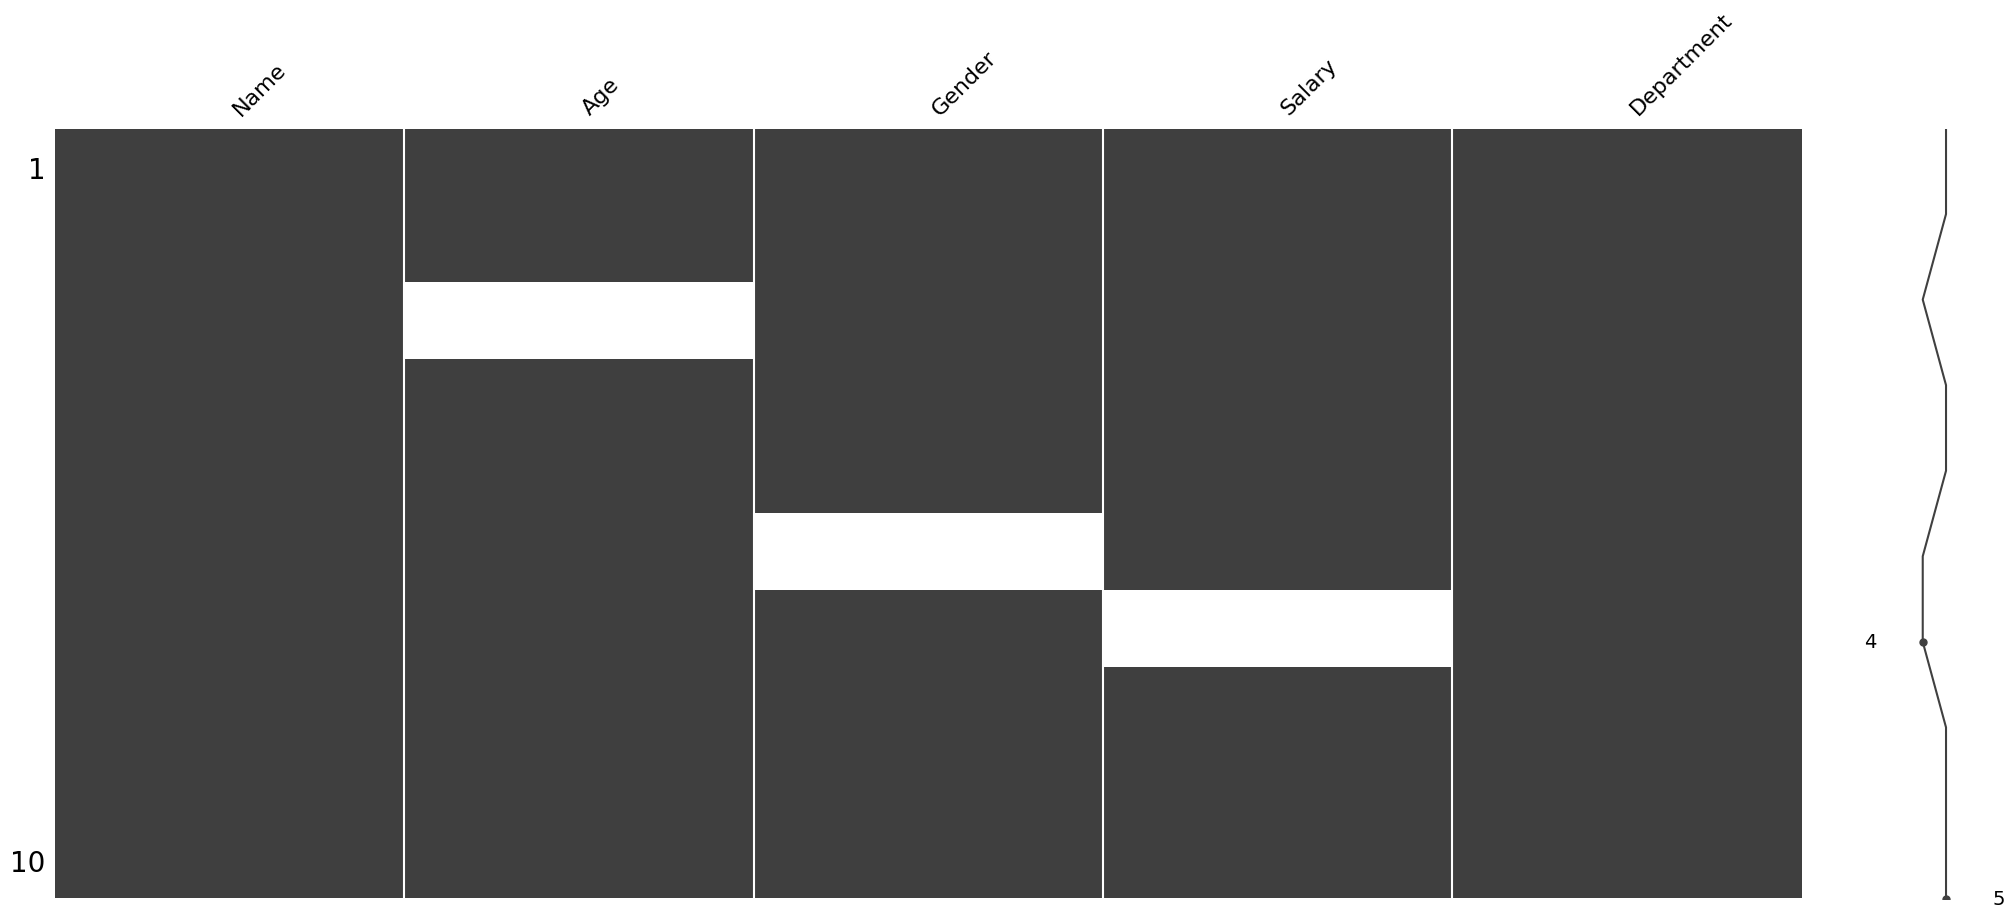

In [13]:
print("\nMissing Data Matrix:")
msno.matrix(df)
plt.show()


Missing Data Bar Chart:


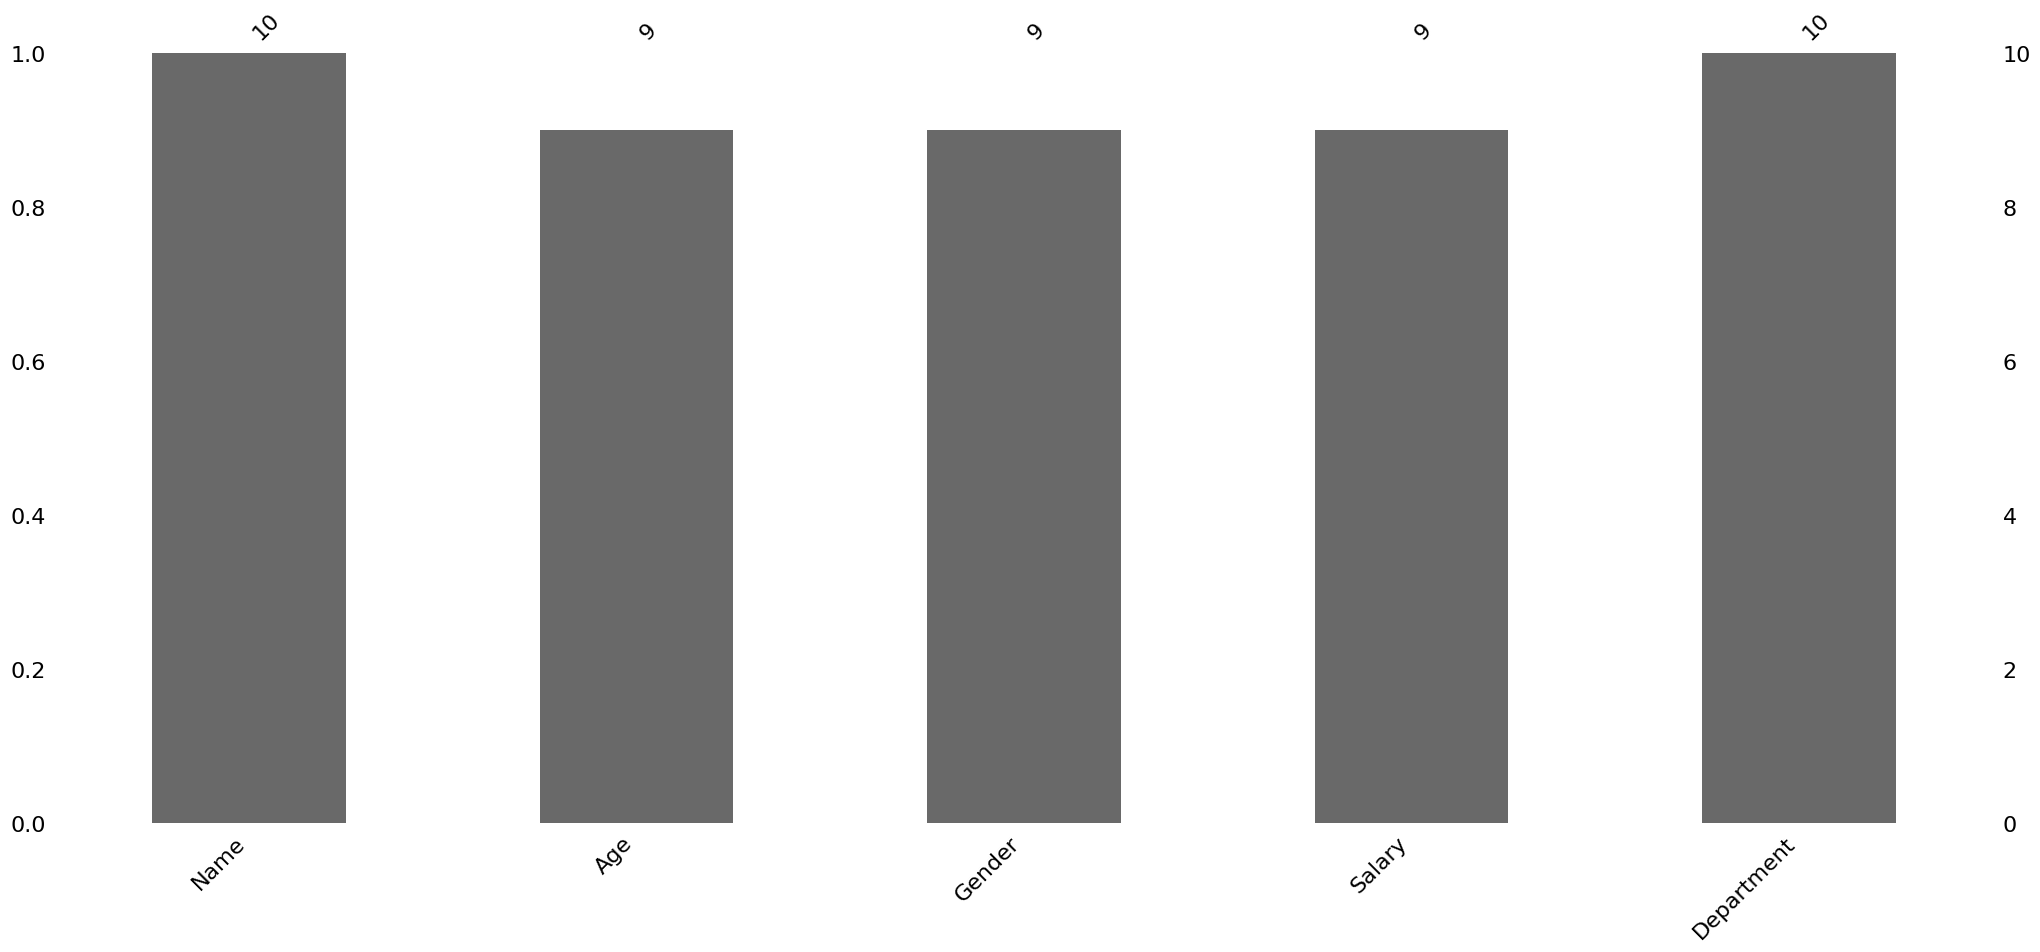

In [14]:
print("\nMissing Data Bar Chart:")
msno.bar(df)
plt.show()


Missing Data Heatmap:


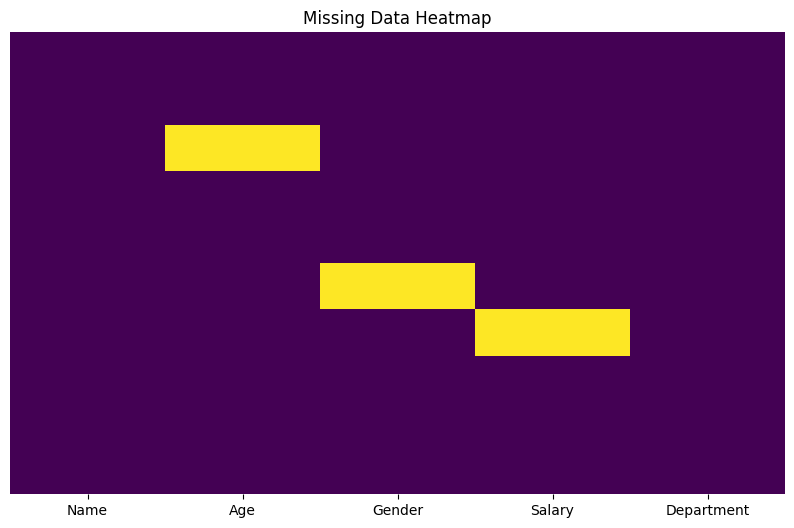

In [15]:
print("\nMissing Data Heatmap:")
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap')
plt.show()

In [16]:
print("\n" + "="*50)
print("METHOD 1: BASIC PANDAS IMPUTATION")
print("="*50)

df_method1 = df.copy()


METHOD 1: BASIC PANDAS IMPUTATION


In [17]:
df_method1['Age'] = df_method1['Age'].fillna(df_method1['Age'].mean())

In [18]:
df_method1['Gender'].fillna(df_method1['Gender'].mode()[0], inplace=True)

/tmp/ipython-input-3270262229.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_method1['Gender'].fillna(df_method1['Gender'].mode()[0], inplace=True)


In [19]:
if 'Salary' in df_method1.columns and df_method1['Salary'].isnull().sum() > 0:
    df_method1['Salary'] = df_method1['Salary'].fillna(df_method1['Salary'].mean())

print("\nNull values after Method 1:")
print(df_method1.isnull().sum())

print("\nDataset after Method 1:")
print(df_method1.head())


Null values after Method 1:
Name          0
Age           0
Gender        0
Salary        0
Department    0
dtype: int64

Dataset after Method 1:
      Name        Age Gender   Salary Department
0    Alice  25.000000      F  50000.0         HR
1      Bob  30.000000      M  60000.0    Finance
2  Charlie  39.555556      M  55000.0         IT
3    David  40.000000      M  58000.0         HR
4      Eve  22.000000      F  52000.0         IT


In [21]:
from sklearn.impute import SimpleImputer

df_method2 = df.copy()

In [22]:
num_imputer = SimpleImputer(strategy='mean')
numerical_cols = df_method2.select_dtypes(include=['int64', 'float64']).columns
df_method2[numerical_cols] = num_imputer.fit_transform(df_method2[numerical_cols])

In [23]:
cat_imputer = SimpleImputer(strategy='most_frequent')
categorical_cols = df_method2.select_dtypes(include=['object']).columns
df_method2[categorical_cols] = cat_imputer.fit_transform(df_method2[categorical_cols])

In [24]:
print("\nNull values after Method 2:")
print(df_method2.isnull().sum())

print("\nDataset after Method 2:")
print(df_method2.head())


Null values after Method 2:
Name          0
Age           0
Gender        0
Salary        0
Department    0
dtype: int64

Dataset after Method 2:
      Name        Age Gender   Salary Department
0    Alice  25.000000      F  50000.0         HR
1      Bob  30.000000      M  60000.0    Finance
2  Charlie  39.555556      M  55000.0         IT
3    David  40.000000      M  58000.0         HR
4      Eve  22.000000      F  52000.0         IT


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [26]:
df_method3 = df.copy()

num_features = df_method3.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = df_method3.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical features: {num_features}")
print(f"Categorical features: {cat_features}")


Numerical features: ['Age', 'Salary']
Categorical features: ['Name', 'Gender', 'Department']


In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features)
    ]
)

In [28]:
df_method3_transformed = preprocessor.fit_transform(df_method3)

print(f"\nTransformed data shape: {df_method3_transformed.shape}")
print(f"Transformed data type: {type(df_method3_transformed)}")


Transformed data shape: (10, 17)
Transformed data type: <class 'scipy.sparse._csr.csr_matrix'>


In [29]:
num_feature_names = num_features
cat_feature_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_features)
all_feature_names = num_feature_names + list(cat_feature_names)

In [30]:
df_method3_final = pd.DataFrame(
    df_method3_transformed.toarray() if hasattr(df_method3_transformed, 'toarray') else df_method3_transformed,
    columns=all_feature_names
)

In [31]:
print("\nTransformed dataset (first 5 rows):")
print(df_method3_final.head())


Transformed dataset (first 5 rows):
        Age    Salary  Name_Alice  Name_Bob  Name_Charlie  Name_David  \
0 -0.531273 -1.923193         1.0       0.0           0.0         0.0   
1 -0.348775  0.549484         0.0       1.0           0.0         0.0   
2  0.000000 -0.686855         0.0       0.0           1.0         0.0   
3  0.016222  0.054948         0.0       0.0           0.0         1.0   
4 -0.640773 -1.428658         0.0       0.0           0.0         0.0   

   Name_Eve  Name_Frank  Name_Grace  Name_Henry  Name_Ivy  Name_Jack  \
0       0.0         0.0         0.0         0.0       0.0        0.0   
1       0.0         0.0         0.0         0.0       0.0        0.0   
2       0.0         0.0         0.0         0.0       0.0        0.0   
3       0.0         0.0         0.0         0.0       0.0        0.0   
4       1.0         0.0         0.0         0.0       0.0        0.0   

   Gender_F  Gender_M  Department_Finance  Department_HR  Department_IT  
0       1.0      

In [32]:
comparison = pd.DataFrame({
    'Original': df.isnull().sum(),
    'Method 1 (Pandas)': df_method1.isnull().sum(),
    'Method 2 (SimpleImputer)': df_method2.isnull().sum()
})

print("\nNull values comparison:")
print(comparison)


Null values comparison:
            Original  Method 1 (Pandas)  Method 2 (SimpleImputer)
Name               0                  0                         0
Age                1                  0                         0
Gender             1                  0                         0
Salary             1                  0                         0
Department         0                  0                         0


<Figure size 1200x600 with 0 Axes>

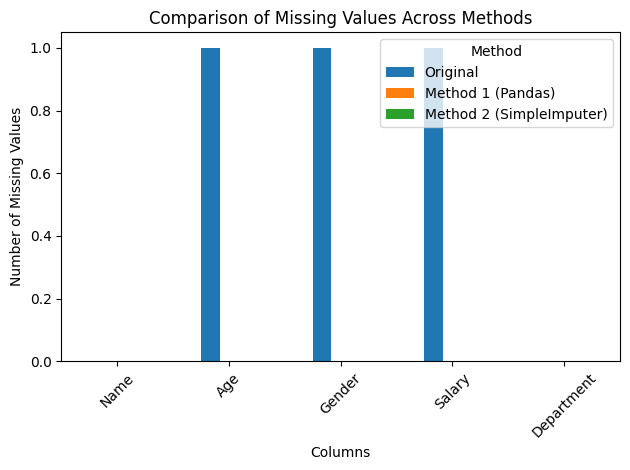

In [33]:
plt.figure(figsize=(12, 6))
comparison.plot(kind='bar')
plt.title('Comparison of Missing Values Across Methods')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.legend(title='Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
df_method1.to_csv('/content/data_method1_pandas.csv', index=False)
df_method2.to_csv('/content/data_method2_simpleimputer.csv', index=False)
df_method3_final.to_csv('/content/data_method3_pipeline.csv', index=False)
